In [1]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import scvelo as scv
import multivelo as mv

import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import sys
sys.path.append('../')
from UTV_metrics import *

In [10]:
model_outdir = 'modeling_results/10_comps/'

In [8]:
adata_rna = anndata.read_h5ad('processed_data/adata_rna.h5ad')

In [12]:
SCV_result = anndata.read_h5ad(model_outdir+'scvelo_result.h5ad')
MV_result = anndata.read_h5ad(model_outdir+'multivelo_result.h5ad')
AA_result = anndata.read_h5ad(model_outdir+'archvelo_result.h5ad')

In [30]:
def map_to_short(x):
    if x.split('.')[0] == 'AG':
        return 'AG'
    else:
        return x
def apply_labelmap(adata, 
              from_label = None, 
              to_label = None,
              map_func = None):
    adata.obs[to_label] = adata.obs[from_label].map(map_func)
    adata.uns[to_label+'_colors'] = adata.uns[from_label+'_colors']

In [31]:
for dat in [adata_rna, SCV_result, MV_result, AA_result]:
    apply_labelmap(dat, from_label = 'cell_type_abbr', to_label = 'cell_type_short_abbr', map_func = map_to_short)

In [13]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)


# Velocity fields

In [16]:
sns.set(style = 'ticks', font_scale = 1)

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


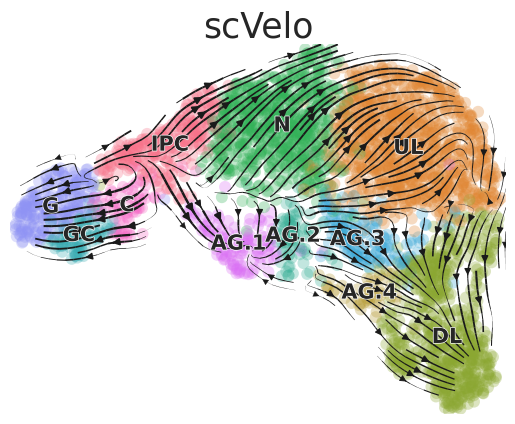

In [17]:
scv.tl.velocity_graph(SCV_result)
scv.tl.latent_time(SCV_result)
scv.pl.velocity_embedding_stream(SCV_result, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = 'scVelo',
                             fontsize = 25,
                            legend_fontsize = 15)
plt.savefig(fig_outdir+'scVelo_results.png', dpi = 600, transparent=True)
plt.savefig(fig_outdir+'scVelo_results.svg', dpi = 600, transparent=True)

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


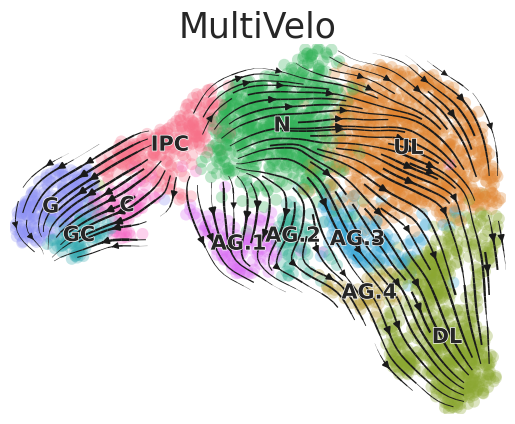

In [18]:
mv.velocity_graph(MV_result)
mv.latent_time(MV_result)
mv.velocity_embedding_stream(MV_result, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = 'MultiVelo',
                             fontsize = 25,
                            legend_fontsize = 15)
plt.savefig(fig_outdir+'Multivelo_results.png', dpi = 600, transparent=True)
plt.savefig(fig_outdir+'Multivelo_results.svg', dpi = 600, transparent=True)

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:08) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


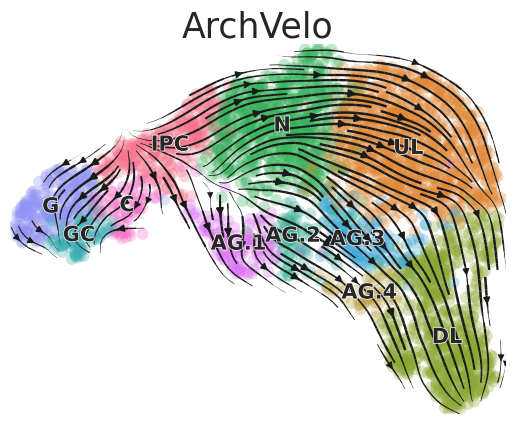

In [20]:
# lik_cutoff = 0.05#np.percentile(AA_result.var['fit_likelihood'], 2)
# AA_result.var['velo_s_genes'] = AA_result.var['fit_likelihood']>lik_cutoff
# AA_result.var['velo_s_norm_genes'] = AA_result.var['fit_likelihood']>lik_cutoff
mv.velocity_graph(AA_result, vkey = 'velo_s')
mv.latent_time(AA_result)
mv.velocity_embedding_stream(AA_result, 
                             #vkey = 'velo_s',
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = 'ArchVelo',
                            fontsize = 25,
                            legend_fontsize = 15)
plt.savefig(fig_outdir+'AA_results.png', dpi = 600, transparent=True)
plt.savefig(fig_outdir+'AA_results.svg', dpi = 600, transparent=True)

# CBD on aggregated edges

In [32]:
inds = np.array([[i]+list(np.nonzero(x)[1]) for (i,x) in enumerate(adata_rna.obsp['distances'])])
SCV_result.uns['neighbors']['indices'] = inds
MV_result.uns['neighbors']['indices'] = inds
AA_result.uns['neighbors']['indices'] = inds

In [33]:
edges = [('IPC', 'N'),
              ('N', 'UL'),
              ('IPC', 'AG'),
              ('AG', 'DL'),
 ]

In [34]:
CBCs = {}

In [39]:
CBCs['scVelo'] = cross_boundary_correctness(
    SCV_result, 
         
    'cell_type_short_abbr', 
    'velocity', 
    edges, 
    x_emb="X_umap", return_raw = True)

In [36]:
CBCs['MultiVelo'] = cross_boundary_correctness(
    MV_result, 
         
    'cell_type_short_abbr', 
    'velo_s_norm', 
    edges, 
    x_emb="X_umap", return_raw = True)

In [37]:
CBCs['ArchVelo'] = cross_boundary_correctness(
    AA_result, 
         
    'cell_type_short_abbr', 
    'velo_s_norm', 
    edges, 
    x_emb="X_umap", return_raw = True)

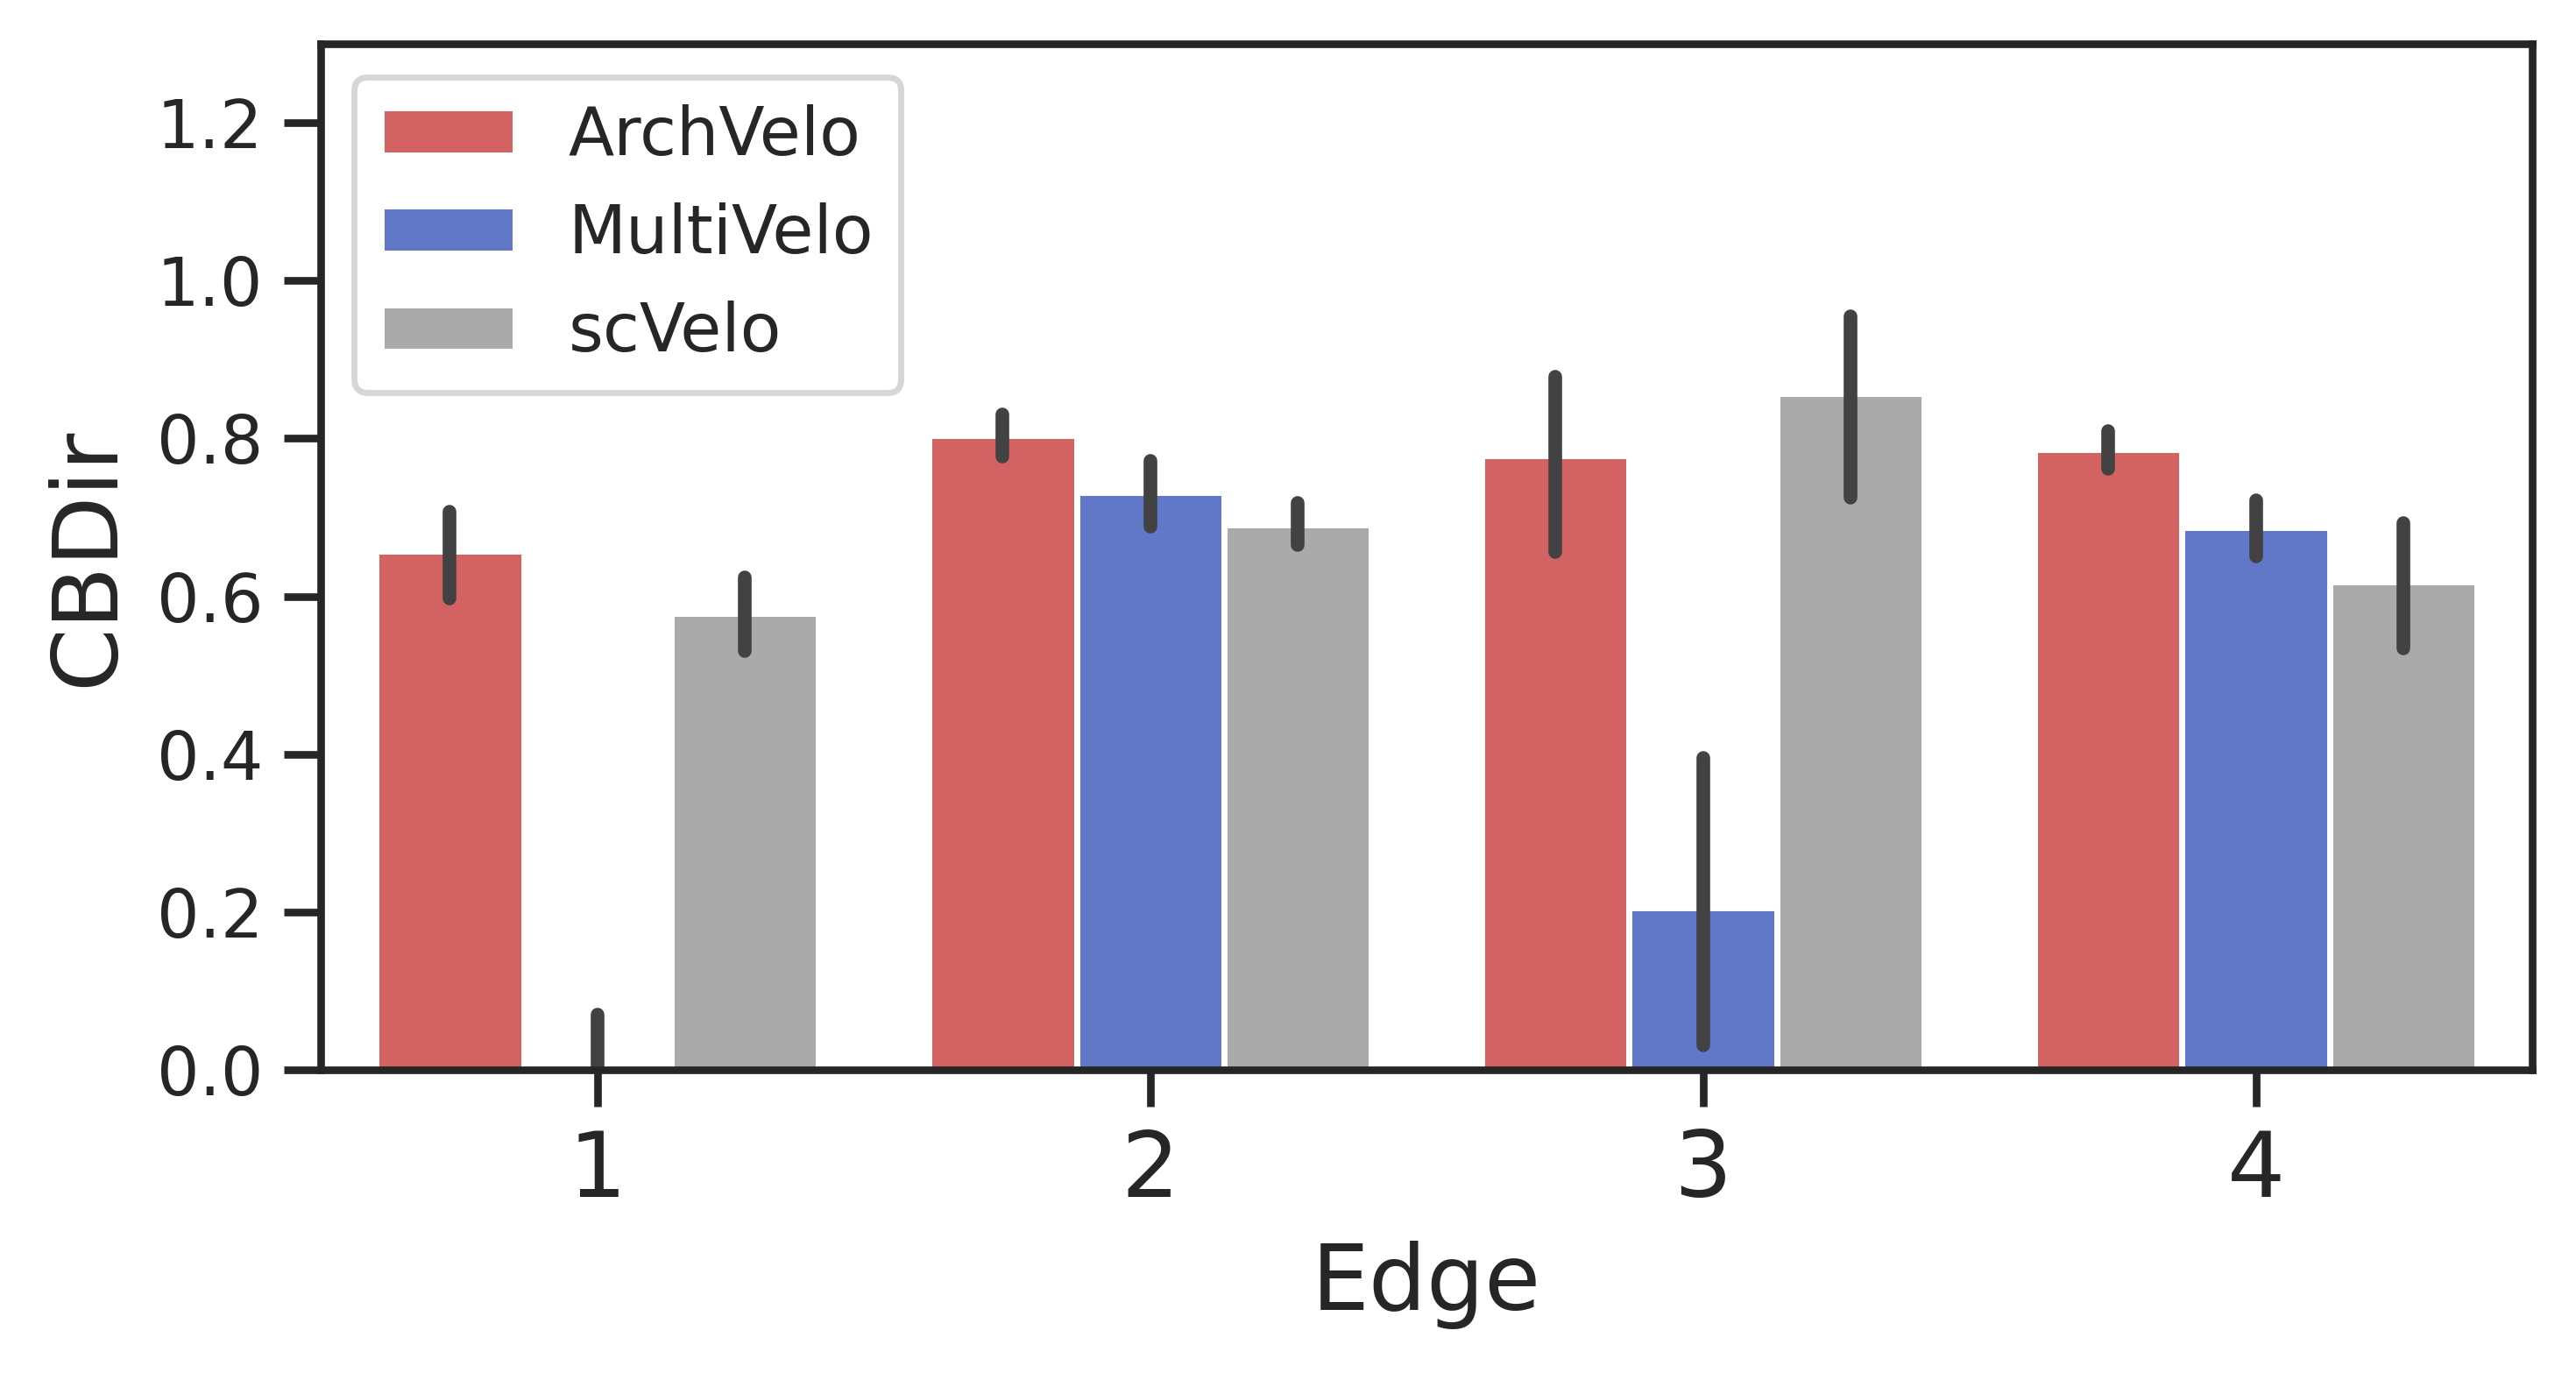

In [40]:
sns.set(style = 'ticks', font_scale = 1)
plt.figure(figsize = (6,3.2), dpi = 500)
methods = CBCs.keys()
all_CBCs = pd.concat([pd.concat([pd.Series(CBCs[met][k]) for k in CBCs[met].keys()],
         keys = [str(x[0]) for x in list(zip(CBCs[met].keys()))]) for met in methods],
          keys = methods, axis = 0).reset_index()
all_CBCs.columns = ['Method', 'Edge', 'Cell','CBD']
sns.barplot(all_CBCs, 
            y = 'CBD',
            x = 'Edge', 
            hue = 'Method' ,
            palette = ['#E64F4F', '#506ED8', '#AAAAAA'],
             hue_order = list(methods)[::-1])
plt.ylim(0, 1.3)
plt.tight_layout()
plt.legend(loc = 'upper left')
plt.xticks(ticks = range(4),
           labels = [str(x) for x in range(1,5)],
          fontsize = 15)
plt.ylabel('CBDir', fontsize = 15)
plt.xlabel('Edge',fontsize = 15)
plt.savefig(fig_outdir+'CBD_results_horizontal_4_edges.png', dpi = 500)
plt.savefig(fig_outdir+'CBD_results_horizontal_4_edges.svg', dpi = 500)

In [41]:
from scipy.stats import wilcoxon, ttest_rel
i=0
for edge in edges:
    i+=1
    cur_df = all_CBCs.loc[all_CBCs['Edge'].isin([str(edge)]),:]
    xx = cur_df.query('Method == "ArchVelo"')['CBD']
    yy = cur_df.query('Method == "MultiVelo"')['CBD']
    #if np.abs(np.mean(xx)-np.mean(yy))>0.05:
    print('i=',i)
    print(edge)
    p = wilcoxon(x = xx, 
             y = yy,
             zero_method='wilcox').pvalue
    print(p)
    if p<0.01/len(edges):
        if np.mean(xx)> np.mean(yy):
            print('ArchVelo')
        else:
            print('MultiVelo')

i= 1
('IPC', 'N')
1.5753513023728927e-26
ArchVelo
i= 2
('N', 'UL')
0.4119532053089938
i= 3
('IPC', 'AG')
4.738103598356247e-07
ArchVelo
i= 4
('AG', 'DL')
2.6092104525918155e-15
ArchVelo


In [42]:
from scipy.stats import wilcoxon, ttest_rel
i=0
for edge in edges:
    i+=1
    cur_df = all_CBCs.loc[all_CBCs['Edge'].isin([str(edge)]),:]
    xx = cur_df.query('Method == "ArchVelo"')['CBD']
    yy = cur_df.query('Method == "scVelo"')['CBD']
    #if np.abs(np.mean(xx)-np.mean(yy))>0.05:
    print('i=',i)
    print(edge)
    p = wilcoxon(x = xx, 
             y = yy,
             zero_method='wilcox').pvalue
    print(p)
    if p<0.01/len(edges):
        if np.mean(xx)> np.mean(yy):
            print('ArchVelo')
        else:
            print('scVelo')

i= 1
('IPC', 'N')
8.077755841692367e-10
ArchVelo
i= 2
('N', 'UL')
2.6445049130231962e-20
ArchVelo
i= 3
('IPC', 'AG')
0.009843661217018962
i= 4
('AG', 'DL')
0.9745536089812848
